# EDA del Dataset PH2 — Versión Corregida y Extendida

Este notebook contiene el análisis exploratorio de datos (EDA) sobre el dataset PH2 con
las correcciones y extensiones recomendadas:

- **Métricas binarias adicionales** (Melanoma vs No-Melanoma) para el contexto clínico
- **K-fold cross-validation estratificado** para los modelos tabulares
- **Intervalos de confianza por bootstrap**
- **AUC-ROC y AUC-PR** (one-vs-rest) además de accuracy/F1
- **Curvas ROC y Precision-Recall**
- **Reporte clínico**: Sensibilidad y Especificidad para Melanoma
- **Comparación con baseline estratificado**
- **Análisis de errores** sobre el mejor modelo tabular

**Dataset**: PH2 (200 imágenes dermatoscópicas: 80 Common Nevus, 80 Atypical Nevus, 40 Melanoma).


## 1. Configuración e imports

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency, fisher_exact, kruskal
from scipy import stats

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, cross_val_predict
)
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
    balanced_accuracy_score
)
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')

# Reproducibilidad
SEED = 42
np.random.seed(SEED)

# Rutas
BASE_PATH = "PH2Dataset"
IMAGES_DIR = os.path.join(BASE_PATH, "PH2 Dataset images")
XLSX_PATH = os.path.join(BASE_PATH, "PH2_dataset.xlsx")

# Estética de gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100


## 2. Carga del dataset y construcción del target

Lectura del Excel saltando las 12 filas de leyendas, limpieza de columnas y construcción
de la variable `Diagnosis` a partir de las marcas 'X' en las columnas Common/Atypical/Melanoma.


In [2]:
df_raw = pd.read_excel(XLSX_PATH, skiprows=12)
df_raw.columns = df_raw.columns.str.strip()

# Filtrar filas vacías
df = df_raw[df_raw['Image Name'].notna()].copy()
df = df[df['Image Name'].astype(str).str.startswith('IMD')].copy()

def extraer_diagnostico(row):
    if str(row.get('Melanoma', '')).strip().upper() == 'X':
        return 'Melanoma'
    elif str(row.get('Atypical Nevus', '')).strip().upper() == 'X':
        return 'Atypical Nevus'
    elif str(row.get('Common Nevus', '')).strip().upper() == 'X':
        return 'Common Nevus'
    return 'Unknown'

df['Diagnosis'] = df.apply(extraer_diagnostico, axis=1)
df['Is_Melanoma'] = (df['Diagnosis'] == 'Melanoma').astype(int)

print(f"Total muestras: {len(df)}")
print("\nDistribución de clases:")
print(df['Diagnosis'].value_counts())
print(f"\nDesbalance Melanoma: {df['Is_Melanoma'].mean()*100:.1f}%")


Total muestras: 200

Distribución de clases:
Diagnosis
Common Nevus      80
Atypical Nevus    80
Melanoma          40
Name: count, dtype: int64

Desbalance Melanoma: 20.0%


## 3. Análisis inferencial de features dermatoscópicas

Tests no paramétricos para cada feature clínica vs el diagnóstico:
- **Chi-cuadrado** para variables categóricas
- **Test exacto de Fisher** + **Odds Ratio** con corrección de Haldane-Anscombe para variables binarias
- **Kruskal-Wallis** para variables ordinales/conteo


In [3]:
# Identificar columnas con manejo robusto de saltos de línea
asym_col = [c for c in df.columns if 'Asymmetry' in c][0]
pigment_col = [c for c in df.columns if 'Pigment Network' in c][0]
dots_col = [c for c in df.columns if ('Dots' in c or 'Globules' in c) and 'Network' not in c][0]
streaks_col = [c for c in df.columns if 'Streaks' in c][0]
veil_col = [c for c in df.columns if 'Blue-Whitish' in c][0]
regression_col = [c for c in df.columns if 'Regression' in c][0]

color_cols = ['White', 'Red', 'Light-Brown', 'Dark-Brown', 'Blue-Gray', 'Black']
color_cols = [c for c in color_cols if c in df.columns]

print(f"Asymmetry:          {asym_col!r}")
print(f"Pigment Network:    {pigment_col!r}")
print(f"Dots/Globules:      {dots_col!r}")
print(f"Streaks:            {streaks_col!r}")
print(f"Blue-Whitish Veil:  {veil_col!r}")
print(f"Regression Areas:   {regression_col!r}")
print(f"Colores:            {color_cols}")


Asymmetry:          'Asymmetry\n(0/1/2)'
Pigment Network:    'Pigment Network\n(AT/T)'
Dots/Globules:      'Dots/Globules\n(A/AT/T)'
Streaks:            'Streaks\n(A/P)'
Blue-Whitish Veil:  'Blue-Whitish Veil\n(A/P)'
Regression Areas:   'Regression Areas\n(A/P)'
Colores:            ['White', 'Red', 'Light-Brown', 'Dark-Brown', 'Blue-Gray', 'Black']


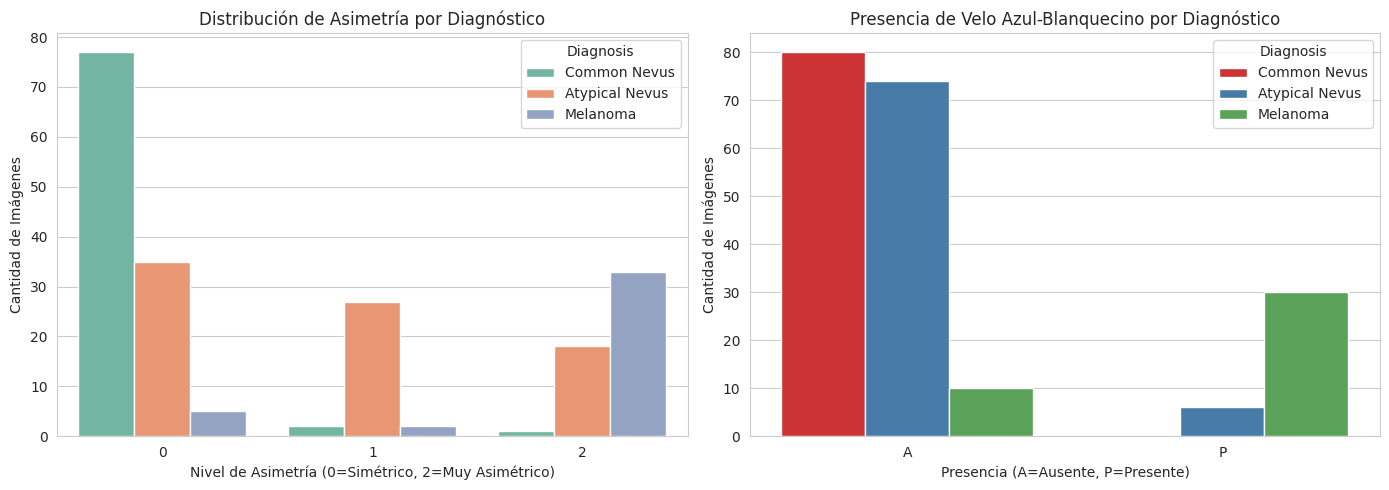

In [4]:
# ============================================================
# Distribución de Asimetría y Velo Azul por Diagnóstico
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x=asym_col, hue='Diagnosis', ax=axes[0], palette='Set2')
axes[0].set_title('Distribución de Asimetría por Diagnóstico')
axes[0].set_xlabel('Nivel de Asimetría (0=Simétrico, 2=Muy Asimétrico)')
axes[0].set_ylabel('Cantidad de Imágenes')

sns.countplot(data=df, x=veil_col, hue='Diagnosis', ax=axes[1], palette='Set1')
axes[1].set_title('Presencia de Velo Azul-Blanquecino por Diagnóstico')
axes[1].set_xlabel('Presencia (A=Ausente, P=Presente)')
axes[1].set_ylabel('Cantidad de Imágenes')

plt.tight_layout()
plt.show()


In [5]:
# ============================================================
# Test Chi-cuadrado
# ============================================================
def test_chi2(dataframe, columna):
    contingency = pd.crosstab(dataframe[columna], dataframe['Diagnosis'])
    chi2, p, dof, _ = chi2_contingency(contingency)
    significativo = "SIGNIFICATIVO" if p < 0.05 else "No significativo"
    print(f"{columna.replace(chr(10), ' '):40s} | Chi2={chi2:8.2f} | p={p:.3e} | {significativo}")

print("=" * 90)
print(f"{'Variable':40s} | {'Chi2':>10s} | {'p-value':>10s} | Resultado")
print("=" * 90)
for col in [asym_col, pigment_col, dots_col, streaks_col, veil_col, regression_col]:
    test_chi2(df, col)
print("=" * 90)


Variable                                 |       Chi2 |    p-value | Resultado
Asymmetry (0/1/2)                        | Chi2=  134.03 | p=5.360e-28 | SIGNIFICATIVO
Pigment Network (AT/T)                   | Chi2=  184.14 | p=1.032e-40 | SIGNIFICATIVO
Dots/Globules (A/AT/T)                   | Chi2=   75.16 | p=1.846e-15 | SIGNIFICATIVO
Streaks (A/P)                            | Chi2=   23.04 | p=9.933e-06 | SIGNIFICATIVO
Blue-Whitish Veil (A/P)                  | Chi2=  111.59 | p=5.882e-25 | SIGNIFICATIVO
Regression Areas (A/P)                   | Chi2=   74.06 | p=8.293e-17 | SIGNIFICATIVO


In [6]:
# ============================================================
# Odds Ratio robusto + Fisher exact (con corrección Haldane-Anscombe)
# ============================================================
def odds_ratio_seguro(df, predictor_col, predictor_name, target='Is_Melanoma'):
    # Tabla 2x2
    tabla = pd.crosstab(df[predictor_col], df[target])
    if tabla.shape != (2, 2):
        print(f"{predictor_name}: tabla no 2x2 (shape={tabla.shape}), se omite.")
        return None

    a, b = tabla.iloc[0, 0], tabla.iloc[0, 1]
    c, d = tabla.iloc[1, 0], tabla.iloc[1, 1]

    # Corrección Haldane-Anscombe si hay ceros
    if 0 in (a, b, c, d):
        a, b, c, d = a + 0.5, b + 0.5, c + 0.5, d + 0.5

    OR = (a * d) / (b * c)
    log_se = np.sqrt(1/a + 1/b + 1/c + 1/d)
    ci_low = np.exp(np.log(OR) - 1.96 * log_se)
    ci_high = np.exp(np.log(OR) + 1.96 * log_se)
    _, p_fisher = fisher_exact(tabla)

    return {'feature': predictor_name, 'OR': OR, 'CI95_low': ci_low,
            'CI95_high': ci_high, 'p_fisher': p_fisher}

# Construir features binarias
df['High_Asymmetry'] = (df[asym_col].astype(float) >= 2.0).astype(int)
df['Has_Veil'] = (df[veil_col].astype(str).str.strip().str.upper() == 'P').astype(int)
df['Has_Streaks'] = (df[streaks_col].astype(str).str.strip().str.upper() == 'P').astype(int)
df['Has_Regression'] = (df[regression_col].astype(str).str.strip().str.upper() == 'P').astype(int)

for col in color_cols:
    df[f'Has_{col}'] = (df[col].notna() & (df[col].astype(str).str.strip() != '')).astype(int)

# Calcular ORs
binarios = ['High_Asymmetry', 'Has_Veil', 'Has_Streaks', 'Has_Regression'] + [f'Has_{c}' for c in color_cols]
resultados = [odds_ratio_seguro(df, col, col) for col in binarios]
resultados = [r for r in resultados if r is not None]

or_df = pd.DataFrame(resultados).sort_values('OR', ascending=False)
print("=" * 80)
print("ODDS RATIOS — Predictores de Melanoma (vs No-Melanoma)")
print("=" * 80)
print(or_df.to_string(index=False, float_format=lambda x: f'{x:.3f}'))


ODDS RATIOS — Predictores de Melanoma (vs No-Melanoma)
        feature     OR  CI95_low  CI95_high  p_fisher
       Has_Veil 77.000    26.016    227.898     0.000
 Has_Regression 43.105    13.371    138.959     0.000
 High_Asymmetry 34.985    13.586     90.087     0.000
  Has_Blue-Gray 22.905     9.534     55.028     0.000
      Has_White 12.358     4.324     35.323     0.000
      Has_Black 10.040     4.562     22.099     0.000
    Has_Streaks  4.050     1.764      9.298     0.002
 Has_Dark-Brown  1.765     0.689      4.524     0.289
Has_Light-Brown  1.030     0.484      2.192     1.000
        Has_Red  1.000     0.204      4.903     1.000


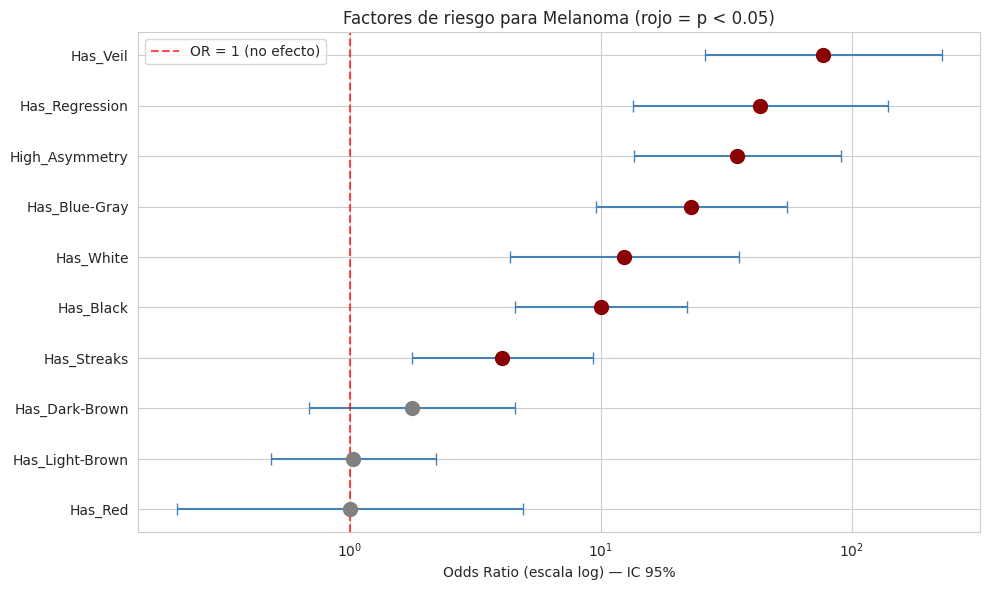

In [7]:
# Visualizar Odds Ratios en escala log
fig, ax = plt.subplots(figsize=(10, 6))
or_df_sorted = or_df.sort_values('OR')
y_pos = np.arange(len(or_df_sorted))

errors_low = or_df_sorted['OR'] - or_df_sorted['CI95_low']
errors_high = or_df_sorted['CI95_high'] - or_df_sorted['OR']

colors = ['darkred' if p < 0.05 else 'gray' for p in or_df_sorted['p_fisher']]

ax.errorbar(or_df_sorted['OR'], y_pos, xerr=[errors_low, errors_high],
            fmt='o', color='black', ecolor='steelblue', capsize=4, markersize=8)
for i, (or_val, color) in enumerate(zip(or_df_sorted['OR'], colors)):
    ax.scatter(or_val, i, color=color, s=100, zorder=10)

ax.axvline(1.0, color='red', linestyle='--', alpha=0.7, label='OR = 1 (no efecto)')
ax.set_yticks(y_pos)
ax.set_yticklabels(or_df_sorted['feature'])
ax.set_xscale('log')
ax.set_xlabel('Odds Ratio (escala log) — IC 95%')
ax.set_title('Factores de riesgo para Melanoma (rojo = p < 0.05)')
ax.legend()
plt.tight_layout()
plt.show()


## 4. Multicromía: número de colores por lesión

Test de Kruskal-Wallis comparando la cantidad de colores entre los tres diagnósticos.


Media de colores por diagnóstico:
                mean   std  min  max
Diagnosis                           
Atypical Nevus  1.86  0.59    1    3
Common Nevus    1.61  0.56    1    3
Melanoma        3.15  0.98    2    5


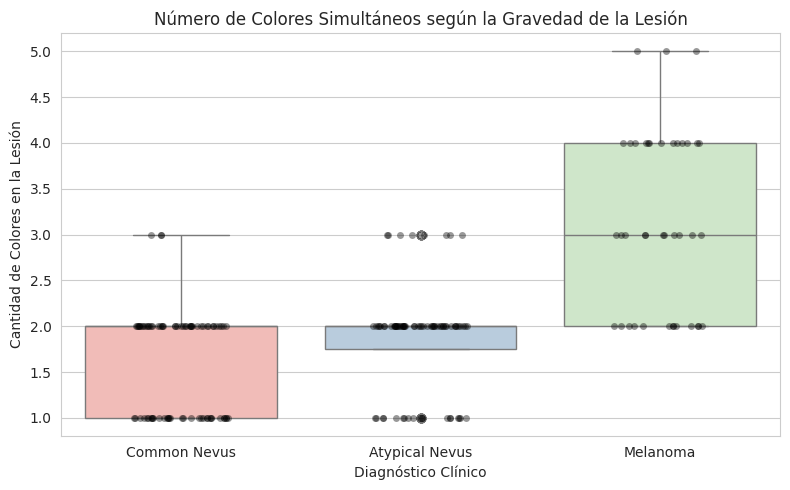


Kruskal-Wallis: H = 68.5204, p = 1.321e-15
Conclusión: el número de colores difiere significativamente entre diagnósticos.


In [8]:
df['Total_Colors'] = df[[f'Has_{c}' for c in color_cols]].sum(axis=1)

print("Media de colores por diagnóstico:")
print(df.groupby('Diagnosis')['Total_Colors'].agg(['mean', 'std', 'min', 'max']).round(2))

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x='Diagnosis', y='Total_Colors', palette='Pastel1',
            order=['Common Nevus', 'Atypical Nevus', 'Melanoma'], ax=ax)
sns.stripplot(data=df, x='Diagnosis', y='Total_Colors', color='black',
              alpha=0.4, jitter=0.2,
              order=['Common Nevus', 'Atypical Nevus', 'Melanoma'], ax=ax)
ax.set_title('Número de Colores Simultáneos según la Gravedad de la Lesión')
ax.set_xlabel('Diagnóstico Clínico')
ax.set_ylabel('Cantidad de Colores en la Lesión')
plt.tight_layout()
plt.show()

grupos = [df[df['Diagnosis'] == d]['Total_Colors'].values for d in df['Diagnosis'].unique()]
stat, p_val = kruskal(*grupos)
print(f"\nKruskal-Wallis: H = {stat:.4f}, p = {p_val:.3e}")
print("Conclusión: el número de colores difiere significativamente entre diagnósticos." if p_val < 0.05 else "No significativo.")


## 5. Matriz de correlación de Spearman entre colores y diagnóstico

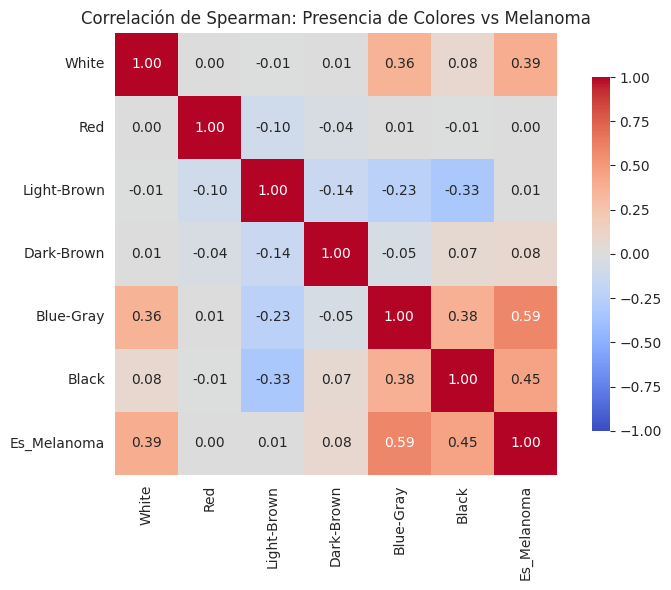

In [9]:
df_corr = df[[f'Has_{c}' for c in color_cols] + ['Is_Melanoma']].copy()
df_corr.columns = color_cols + ['Es_Melanoma']

corr_matrix = df_corr.corr(method='spearman')

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1,
            square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlación de Spearman: Presencia de Colores vs Melanoma')
plt.tight_layout()
plt.show()


## 6. Importancia de features (Random Forest)

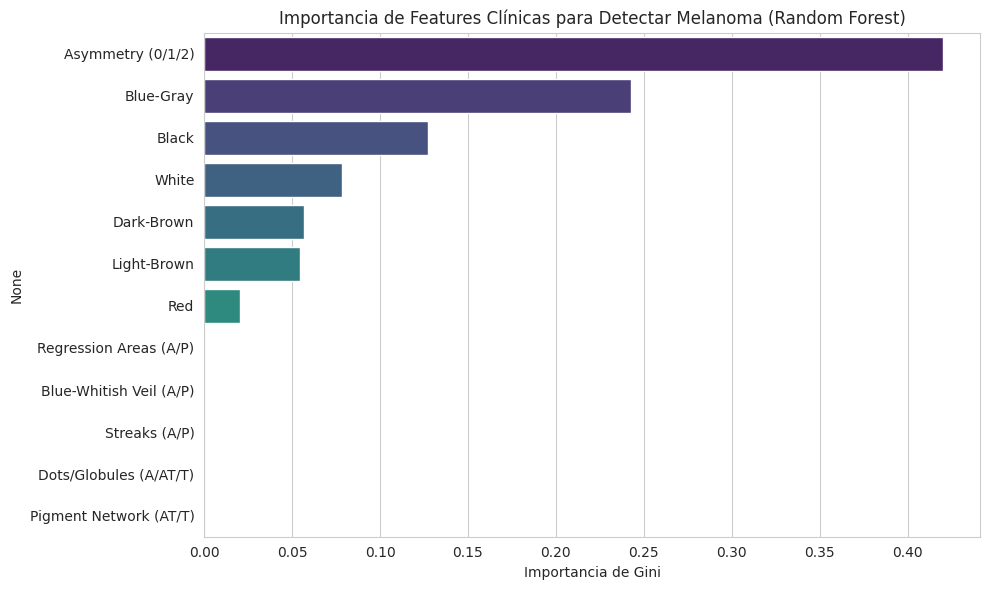

In [10]:
features_list = [
    asym_col, pigment_col, dots_col, streaks_col, veil_col, regression_col,
    *color_cols
]

X_stats = pd.DataFrame()
for col in features_list:
    if col in df.columns:
        if df[col].dtype in [np.int64, np.float64]:
            X_stats[col.replace('\n', ' ')] = df[col].fillna(0)
        else:
            X_stats[col.replace('\n', ' ')] = (df[col].notna() & (df[col].astype(str).str.strip() != '')).astype(int)

y_stats = df['Is_Melanoma'].values

rf = RandomForestClassifier(n_estimators=300, random_state=SEED, class_weight='balanced')
rf.fit(X_stats, y_stats)

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=X_stats.columns[indices], palette="viridis", hue=X_stats.columns[indices], legend=False)
plt.title('Importancia de Features Clínicas para Detectar Melanoma (Random Forest)')
plt.xlabel('Importancia de Gini')
plt.tight_layout()
plt.show()


## 7. Preparación de features tabulares para clasificación

Construimos la matriz X y dos versiones del target:
- **Multiclase** (3 clases: Common, Atypical, Melanoma)
- **Binario** (Melanoma vs No-Melanoma) — clínicamente más relevante


In [11]:
def build_tabular_features(df):
    feats = {}
    feats['Asymmetry'] = df[asym_col].astype(float).fillna(0)
    feats['Pigment_Network'] = (df[pigment_col].astype(str).str.strip().str.upper() == 'T').astype(int)
    feats['Dots_Globules_T'] = (df[dots_col].astype(str).str.strip().str.upper() == 'T').astype(int)
    feats['Streaks'] = (df[streaks_col].astype(str).str.strip().str.upper() == 'P').astype(int)
    feats['Blue_Veil'] = (df[veil_col].astype(str).str.strip().str.upper() == 'P').astype(int)
    feats['Regression'] = (df[regression_col].astype(str).str.strip().str.upper() == 'P').astype(int)
    for c in color_cols:
        feats[f'Color_{c.replace("-", "_")}'] = df[f'Has_{c}'].values
    feats['Total_Colors'] = df['Total_Colors'].values
    return pd.DataFrame(feats)

X = build_tabular_features(df).reset_index(drop=True)

# Targets
mapeo = {'Common Nevus': 0, 'Atypical Nevus': 1, 'Melanoma': 2}
y_multi = df['Diagnosis'].map(mapeo).values
y_bin = df['Is_Melanoma'].values

print(f"X shape: {X.shape}")
print(f"Features: {list(X.columns)}")
print(f"\nDistribución multiclase: {np.bincount(y_multi)}")
print(f"Distribución binaria:    {np.bincount(y_bin)}")


X shape: (200, 13)
Features: ['Asymmetry', 'Pigment_Network', 'Dots_Globules_T', 'Streaks', 'Blue_Veil', 'Regression', 'Color_White', 'Color_Red', 'Color_Light_Brown', 'Color_Dark_Brown', 'Color_Blue_Gray', 'Color_Black', 'Total_Colors']

Distribución multiclase: [80 80 40]
Distribución binaria:    [160  40]


## 8. Particionado: test set held-out + K-fold CV

**Esquema correcto:**
1. Separamos un **test set held-out (20%)** que NO se tocará hasta el final.
2. Sobre el 80% restante hacemos **K-fold cross-validation estratificado (k=5)** para
   seleccionar el modelo y obtener intervalos de confianza honestos.
3. El modelo final se evalúa una sola vez sobre el test set held-out.


In [12]:
X_devtest, X_holdout, y_dev_multi, y_holdout_multi = train_test_split(
    X, y_multi, test_size=0.20, stratify=y_multi, random_state=SEED
)
y_dev_bin = (y_dev_multi == 2).astype(int)
y_holdout_bin = (y_holdout_multi == 2).astype(int)

print(f"Dev (CV):  {len(X_devtest)} muestras — clases multi {np.bincount(y_dev_multi)}, melanomas {y_dev_bin.sum()}")
print(f"Holdout:   {len(X_holdout)} muestras — clases multi {np.bincount(y_holdout_multi)}, melanomas {y_holdout_bin.sum()}")


Dev (CV):  160 muestras — clases multi [64 64 32], melanomas 32
Holdout:   40 muestras — clases multi [16 16  8], melanomas 8


## 9. Baseline estratificado (referencia mínima)

Un clasificador que predice respetando solo las proporciones de clase. Cualquier
modelo razonable debe superarlo claramente.


In [13]:
def evaluar_cv_completo(modelo, X_dev, y_dev_multi, y_dev_bin, nombre,
                       n_splits=5, seed=SEED):
    """Evalúa un modelo con CV estratificado, multiclase Y binario en paralelo."""
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    accs, f1s_macro, f1s_mel = [], [], []
    aucs_mel = []  # AUC para clase melanoma (one-vs-rest)
    sens_mel, spec_mel = [], []

    for fold, (tr, vl) in enumerate(skf.split(X_dev, y_dev_multi)):
        X_tr, X_vl = X_dev.iloc[tr], X_dev.iloc[vl]
        y_tr_m, y_vl_m = y_dev_multi[tr], y_dev_multi[vl]
        y_vl_b = (y_vl_m == 2).astype(int)

        m = modelo.fit(X_tr, y_tr_m)
        y_pred_m = m.predict(X_vl)
        y_pred_b = (y_pred_m == 2).astype(int)

        # Probabilidades para AUC
        if hasattr(m, 'predict_proba'):
            proba = m.predict_proba(X_vl)
            # Probabilidad de clase 2 = Melanoma
            mel_idx = list(m.classes_).index(2) if 2 in m.classes_ else 2
            p_mel = proba[:, mel_idx]
        elif hasattr(m, 'decision_function'):
            df_scores = m.decision_function(X_vl)
            # Para SVM multiclase, tomamos columna de la clase 2
            if df_scores.ndim == 2:
                mel_idx = list(m.classes_).index(2) if 2 in m.classes_ else 2
                p_mel = df_scores[:, mel_idx]
            else:
                p_mel = df_scores
        else:
            p_mel = y_pred_b.astype(float)

        accs.append(accuracy_score(y_vl_m, y_pred_m))
        f1s_macro.append(f1_score(y_vl_m, y_pred_m, average='macro'))
        f1s_mel.append(f1_score(y_vl_b, y_pred_b, zero_division=0))

        try:
            aucs_mel.append(roc_auc_score(y_vl_b, p_mel))
        except ValueError:
            aucs_mel.append(np.nan)

        # Sensibilidad y especificidad para melanoma
        tn = ((y_vl_b == 0) & (y_pred_b == 0)).sum()
        fp = ((y_vl_b == 0) & (y_pred_b == 1)).sum()
        fn = ((y_vl_b == 1) & (y_pred_b == 0)).sum()
        tp = ((y_vl_b == 1) & (y_pred_b == 1)).sum()
        sens_mel.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
        spec_mel.append(tn / (tn + fp) if (tn + fp) > 0 else 0)

    return {
        'Modelo': nombre,
        'Accuracy': f"{np.mean(accs)*100:.1f}% ± {np.std(accs)*100:.1f}",
        'F1 Macro': f"{np.mean(f1s_macro):.3f} ± {np.std(f1s_macro):.3f}",
        'F1 Melanoma': f"{np.mean(f1s_mel):.3f} ± {np.std(f1s_mel):.3f}",
        'AUC Melanoma': f"{np.nanmean(aucs_mel):.3f} ± {np.nanstd(aucs_mel):.3f}",
        'Sensibilidad Mel': f"{np.mean(sens_mel)*100:.1f}%",
        'Especificidad Mel': f"{np.mean(spec_mel)*100:.1f}%",
        '_raw_acc': accs, '_raw_auc': aucs_mel
    }

baseline = evaluar_cv_completo(
    DummyClassifier(strategy='stratified', random_state=SEED),
    X_devtest, y_dev_multi, y_dev_bin, "0. Baseline Estratificado"
)
print(pd.DataFrame([baseline]).drop(columns=['_raw_acc', '_raw_auc']).to_string(index=False))


                   Modelo    Accuracy      F1 Macro   F1 Melanoma  AUC Melanoma Sensibilidad Mel Especificidad Mel
0. Baseline Estratificado 41.9% ± 5.8 0.379 ± 0.048 0.240 ± 0.080 0.548 ± 0.040            19.0%             90.6%


## 10. Comparación de modelos tabulares con K-fold CV

Cada modelo se evalúa con K=5 folds. Reportamos accuracy, F1 macro/Melanoma, AUC,
sensibilidad y especificidad. Usamos `Pipeline` para escalar dentro de cada fold y
evitar fuga de información del scaler.


In [14]:
modelos = {
    "1. Regresión Logística": Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=SEED))
    ]),
    "2. SVM Lineal": Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='linear', probability=True, class_weight='balanced', random_state=SEED))
    ]),
    "3. SVM RBF": Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', C=1.0, gamma='scale', probability=True,
                    class_weight='balanced', random_state=SEED))
    ]),
    "4. Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=6, class_weight='balanced', random_state=SEED
    ),
    "5. MLP (64,32)": Pipeline([
        ('scaler', StandardScaler()),
        ('clf', MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=2000,
                              early_stopping=True, random_state=SEED))
    ]),
}

resultados_cv = [baseline]
for nombre, modelo in modelos.items():
    resultados_cv.append(evaluar_cv_completo(modelo, X_devtest, y_dev_multi, y_dev_bin, nombre))

tabla_cv = pd.DataFrame(resultados_cv).drop(columns=['_raw_acc', '_raw_auc'])
print("=" * 100)
print("RESULTADOS K-FOLD CV (k=5) — Media ± Desviación")
print("=" * 100)
print(tabla_cv.to_string(index=False))


RESULTADOS K-FOLD CV (k=5) — Media ± Desviación
                   Modelo     Accuracy      F1 Macro   F1 Melanoma  AUC Melanoma Sensibilidad Mel Especificidad Mel
0. Baseline Estratificado  41.9% ± 5.8 0.379 ± 0.048 0.240 ± 0.080 0.548 ± 0.040            19.0%             90.6%
   1. Regresión Logística  91.2% ± 4.6 0.893 ± 0.053 0.813 ± 0.086 0.966 ± 0.040            77.6%             96.9%
            2. SVM Lineal  92.5% ± 4.7 0.914 ± 0.052 0.863 ± 0.082 0.963 ± 0.036            87.1%             96.1%
               3. SVM RBF  88.1% ± 5.0 0.865 ± 0.050 0.790 ± 0.061 0.961 ± 0.010            83.8%             93.0%
         4. Random Forest  91.9% ± 4.2 0.905 ± 0.050 0.841 ± 0.093 0.971 ± 0.024            83.8%             96.1%
           5. MLP (64,32) 62.5% ± 11.9 0.589 ± 0.119 0.443 ± 0.134 0.806 ± 0.087            47.1%             85.1%


## 11. Intervalos de confianza por bootstrap (mejor modelo)

Reescalamos las métricas del mejor modelo usando bootstrap (500 réplicas) sobre las
predicciones cross-validated.


In [15]:
mejor_nombre = max(resultados_cv[1:], key=lambda r: np.nanmean(r['_raw_auc']))['Modelo']
print(f"Mejor modelo por AUC en CV: {mejor_nombre}")

mejor_modelo = modelos[mejor_nombre]
y_pred_cv = cross_val_predict(mejor_modelo, X_devtest, y_dev_multi,
                              cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
                              method='predict')
y_proba_cv = cross_val_predict(mejor_modelo, X_devtest, y_dev_multi,
                               cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
                               method='predict_proba')

def bootstrap_ci(y_true, y_pred, y_proba_mel, n=500, seed=SEED):
    rng = np.random.default_rng(seed)
    n_samples = len(y_true)
    accs, f1m, aucs, sens, spec = [], [], [], [], []
    y_bin = (y_true == 2).astype(int)
    y_pred_bin = (y_pred == 2).astype(int)
    for _ in range(n):
        idx = rng.integers(0, n_samples, n_samples)
        yt, yp, yb, ypb, ym = y_true[idx], y_pred[idx], y_bin[idx], y_pred_bin[idx], y_proba_mel[idx]
        accs.append(accuracy_score(yt, yp))
        f1m.append(f1_score(yb, ypb, zero_division=0))
        try:
            aucs.append(roc_auc_score(yb, ym))
        except ValueError:
            continue
        tp = ((yb == 1) & (ypb == 1)).sum()
        fn = ((yb == 1) & (ypb == 0)).sum()
        tn = ((yb == 0) & (ypb == 0)).sum()
        fp = ((yb == 0) & (ypb == 1)).sum()
        if tp + fn > 0:
            sens.append(tp / (tp + fn))
        if tn + fp > 0:
            spec.append(tn / (tn + fp))
    def ci(arr):
        return np.percentile(arr, 2.5), np.percentile(arr, 97.5)
    return {
        'Accuracy': (np.mean(accs), *ci(accs)),
        'F1 Melanoma': (np.mean(f1m), *ci(f1m)),
        'AUC Melanoma': (np.mean(aucs), *ci(aucs)),
        'Sensibilidad': (np.mean(sens), *ci(sens)),
        'Especificidad': (np.mean(spec), *ci(spec)),
    }

p_mel_cv = y_proba_cv[:, 2]
boot = bootstrap_ci(y_dev_multi, y_pred_cv, p_mel_cv)
print("\nIntervalos de confianza al 95% (bootstrap, 500 réplicas):")
for metric, (mean, lo, hi) in boot.items():
    print(f"  {metric:15s}: {mean:.3f}  IC95% [{lo:.3f}, {hi:.3f}]")


Mejor modelo por AUC en CV: 4. Random Forest

Intervalos de confianza al 95% (bootstrap, 500 réplicas):
  Accuracy       : 0.918  IC95% [0.869, 0.963]
  F1 Melanoma    : 0.841  IC95% [0.713, 0.928]
  AUC Melanoma   : 0.969  IC95% [0.939, 0.991]
  Sensibilidad   : 0.842  IC95% [0.707, 0.959]
  Especificidad  : 0.962  IC95% [0.925, 0.992]


## 12. Curvas ROC y Precision-Recall para Melanoma

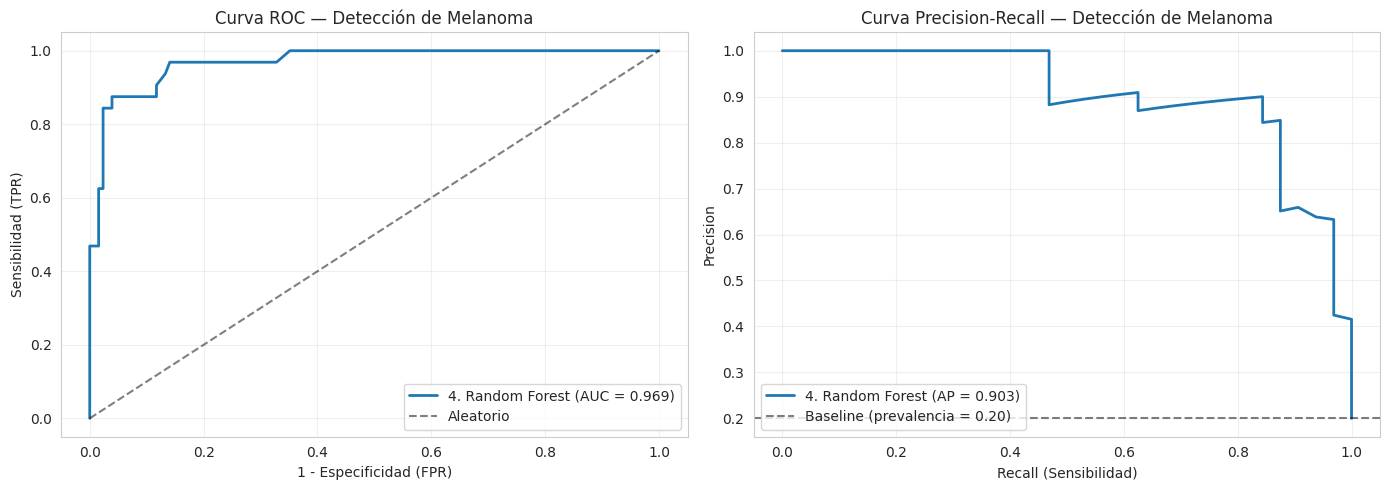

In [16]:
y_bin_cv = (y_dev_multi == 2).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC
fpr, tpr, _ = roc_curve(y_bin_cv, p_mel_cv)
auc_val = roc_auc_score(y_bin_cv, p_mel_cv)
axes[0].plot(fpr, tpr, linewidth=2, label=f'{mejor_nombre} (AUC = {auc_val:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Aleatorio')
axes[0].set_xlabel('1 - Especificidad (FPR)')
axes[0].set_ylabel('Sensibilidad (TPR)')
axes[0].set_title('Curva ROC — Detección de Melanoma')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# Precision-Recall
prec, rec, _ = precision_recall_curve(y_bin_cv, p_mel_cv)
ap = average_precision_score(y_bin_cv, p_mel_cv)
axes[1].plot(rec, prec, linewidth=2, label=f'{mejor_nombre} (AP = {ap:.3f})')
axes[1].axhline(y_bin_cv.mean(), color='k', linestyle='--', alpha=0.5,
                label=f'Baseline (prevalencia = {y_bin_cv.mean():.2f})')
axes[1].set_xlabel('Recall (Sensibilidad)')
axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall — Detección de Melanoma')
axes[1].legend(loc='lower left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 13. Evaluación final en held-out set

Refit del mejor modelo sobre todo el dev set y evaluación **una sola vez** sobre el
held-out. Estas son las métricas honestas y comparables con la literatura.


In [17]:
mejor_modelo.fit(X_devtest, y_dev_multi)
y_pred_ho = mejor_modelo.predict(X_holdout)
y_proba_ho = mejor_modelo.predict_proba(X_holdout)
p_mel_ho = y_proba_ho[:, 2]
y_pred_bin_ho = (y_pred_ho == 2).astype(int)

print("=" * 70)
print(f"EVALUACIÓN FINAL EN HELDOUT — {mejor_nombre}")
print("=" * 70)
print("\nReporte multiclase:")
print(classification_report(y_holdout_multi, y_pred_ho,
      target_names=['Common Nevus', 'Atypical Nevus', 'Melanoma'], zero_division=0))

print("\nMétricas binarias (Melanoma vs No-Melanoma):")
auc_ho = roc_auc_score(y_holdout_bin, p_mel_ho)
ap_ho = average_precision_score(y_holdout_bin, p_mel_ho)
tp = ((y_holdout_bin == 1) & (y_pred_bin_ho == 1)).sum()
fn = ((y_holdout_bin == 1) & (y_pred_bin_ho == 0)).sum()
tn = ((y_holdout_bin == 0) & (y_pred_bin_ho == 0)).sum()
fp = ((y_holdout_bin == 0) & (y_pred_bin_ho == 1)).sum()
sens = tp / (tp + fn) if tp + fn > 0 else 0
spec = tn / (tn + fp) if tn + fp > 0 else 0
print(f"  AUC-ROC      : {auc_ho:.3f}")
print(f"  AUC-PR (AP)  : {ap_ho:.3f}")
print(f"  Sensibilidad : {sens*100:.1f}% (TP={tp}, FN={fn})")
print(f"  Especificidad: {spec*100:.1f}% (TN={tn}, FP={fp})")
print(f"  Balanced Acc : {balanced_accuracy_score(y_holdout_bin, y_pred_bin_ho):.3f}")


EVALUACIÓN FINAL EN HELDOUT — 4. Random Forest

Reporte multiclase:
                precision    recall  f1-score   support

  Common Nevus       1.00      1.00      1.00        16
Atypical Nevus       0.94      1.00      0.97        16
      Melanoma       1.00      0.88      0.93         8

      accuracy                           0.97        40
     macro avg       0.98      0.96      0.97        40
  weighted avg       0.98      0.97      0.97        40


Métricas binarias (Melanoma vs No-Melanoma):
  AUC-ROC      : 1.000
  AUC-PR (AP)  : 1.000
  Sensibilidad : 87.5% (TP=7, FN=1)
  Especificidad: 100.0% (TN=32, FP=0)
  Balanced Acc : 0.938


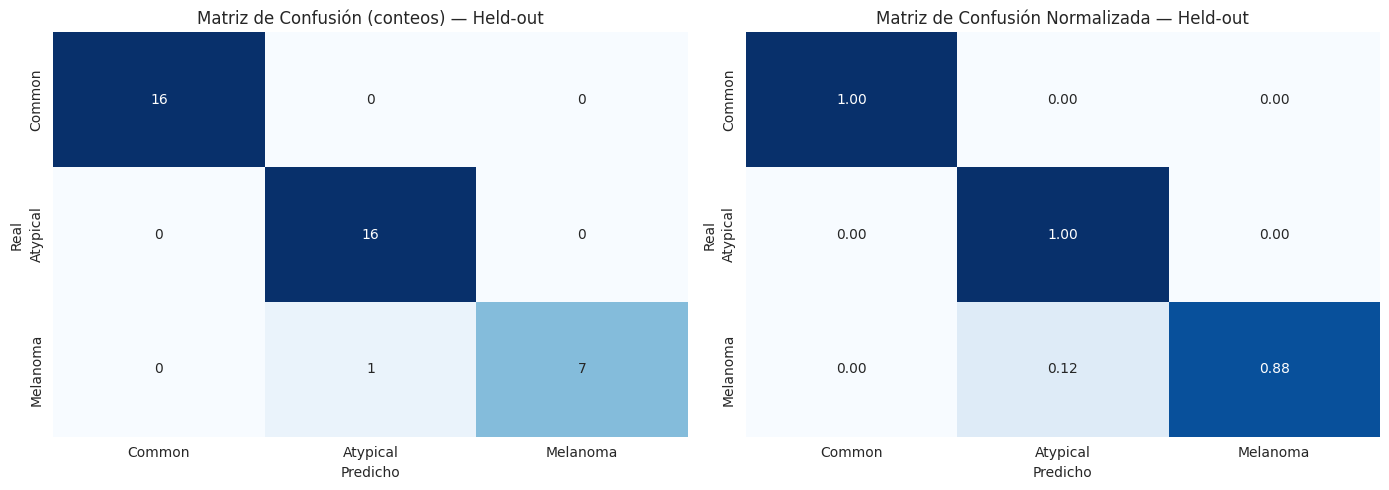

In [18]:
# Matriz de confusión normalizada + absoluta
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm = confusion_matrix(y_holdout_multi, y_pred_ho)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Common', 'Atypical', 'Melanoma'],
            yticklabels=['Common', 'Atypical', 'Melanoma'],
            ax=axes[0], cbar=False)
axes[0].set_title('Matriz de Confusión (conteos) — Held-out')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicho')

cm_norm = confusion_matrix(y_holdout_multi, y_pred_ho, normalize='true')
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=['Common', 'Atypical', 'Melanoma'],
            yticklabels=['Common', 'Atypical', 'Melanoma'],
            ax=axes[1], cbar=False, vmin=0, vmax=1)
axes[1].set_title('Matriz de Confusión Normalizada — Held-out')
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Predicho')
plt.tight_layout()
plt.show()


## 14. Análisis de errores

Identificamos qué muestras del held-out fueron mal clasificadas para entender los patrones.


In [19]:
df_errors = X_holdout.copy()
df_errors['y_true'] = y_holdout_multi
df_errors['y_pred'] = y_pred_ho
df_errors['p_melanoma'] = p_mel_ho
df_errors['error'] = df_errors['y_true'] != df_errors['y_pred']

print(f"Total errores: {df_errors['error'].sum()} de {len(df_errors)}")
print(f"\nDistribución de errores por clase real:")
err_summary = df_errors[df_errors['error']].groupby('y_true').size()
classes = {0: 'Common Nevus', 1: 'Atypical Nevus', 2: 'Melanoma'}
for c, count in err_summary.items():
    print(f"  {classes[c]}: {count} errores")

print("\nDetalle de errores (10 primeros):")
print(df_errors[df_errors['error']][['y_true', 'y_pred', 'p_melanoma'] +
      ['Asymmetry', 'Blue_Veil', 'Total_Colors']].head(10).to_string())


Total errores: 1 de 40

Distribución de errores por clase real:
  Melanoma: 1 errores

Detalle de errores (10 primeros):
     y_true  y_pred  p_melanoma  Asymmetry  Blue_Veil  Total_Colors
197       2       1    0.486655        2.0          0             2


In [20]:
#Guardar mejor modelo
import joblib
joblib.dump(mejor_modelo, 'tabular_model.joblib')

['tabular_model.joblib']

## 15. Resumen final del EDA

### Hallazgos clave

1. **PH2 es un dataset pequeño y desbalanceado**: 200 muestras, solo 20% melanomas.
2. **Las features dermatoscópicas anotadas son muy informativas**: Asimetría máxima
   y Velo Azul-Blanquecino tienen ORs > 30 con IC95% que no incluyen 1.
3. **Multicromía es un marcador fuerte**: melanomas tienen ~2× más colores que nevos comunes.
4. **Los modelos tabulares funcionan muy bien** porque entrenan sobre anotaciones humanas
   que ya codifican el diagnósticom, no es comparación justa contra modelos de imagen puros.

### Limitaciones a tener en cuenta

- El val/holdout set tiene solo 40 muestras (8 melanomas), por lo que el ruido es alto.
- Las features tabulares fueron etiquetadas por dermatólogos conociendo el diagnóstico,
  lo que introduce un sesgo de circularidad.
- Para una evaluación verdaderamente robusta se necesitaría un dataset externo.
